In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import math
import numpy as np

In [ ]:
clima = pd.read_csv('clima.csv')
clima

,temperature_c,evaporation_mm_day
0,10.00,0.990
1,10.25,0.881
2,10.50,1.056
3,10.76,1.250
4,11.01,0.918
...,...,...
115,38.99,9.113
116,39.24,9.230
117,39.50,9.191
118,39.75,9.846


Text(0, 0.5, 'Evaporação (mm/dia)')

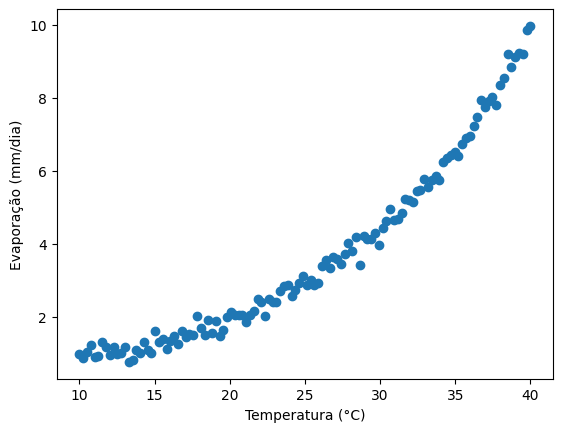

In [ ]:



plt.scatter(clima['temperature_c'], clima['evaporation_mm_day'])
plt.xlabel('Temperatura (°C)')
plt.ylabel('Evaporação (mm/dia)')

#Resposta Parte 1
#nos oobservamos um pico em alguns moentos mas apos uma dada temperatura
#a evaporação se mantem retilinea no valor zero






In [ ]:
#fase do 2 da atv modelagem

def E(T,a,b):
  return a*np.exp(b*T)
parameter = sp.optimize.curve_fit(E,clima['temperature_c'],clima['evaporation_mm_day'])
a,b=parameter
print(a)


[2.09379555e-14 9.99999992e-01]


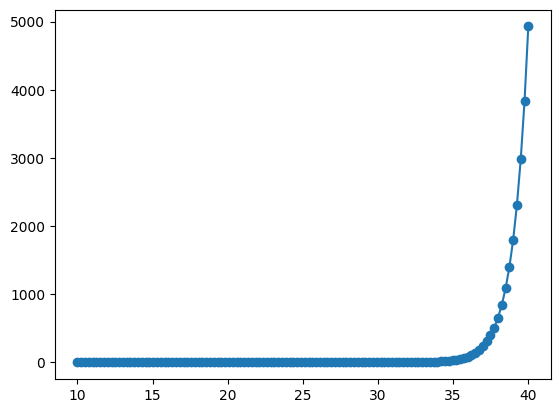

In [ ]:
a = 2.09379555e-14
b = 0.999999992

def E(T,a,b):
  return a*np.exp(b*T)
E = E(clima['temperature_c'],a,b)
plt.scatter(clima['temperature_c'],E)
plt.plot(clima['temperature_c'],E)




(-10.0, 10.0)

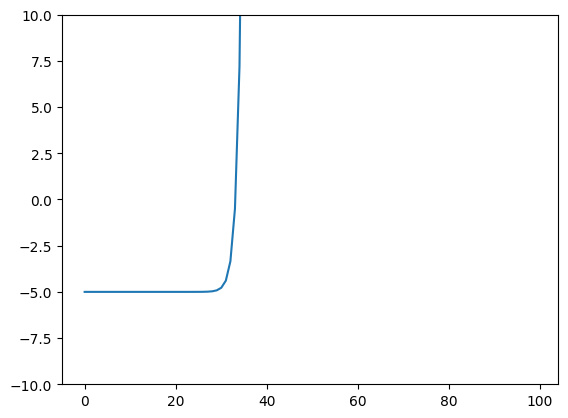

In [ ]:
A = 2.09379555e-14
B = 0.999999992
b =  35
a = 33

def f(x):
     global A,B
     return A*np.exp(B*x) - 5







def funcao():
    i=0
    x = 0
    global a,b
    ai =  a
    bi = b
    if (np.sign(f(a)) * np.sign(f(b))) != -1:
        return 0
    elif (np.sign(f(a)) * np.sign(f(b))) == -1:
        while(i < 1000):
            x = (ai + bi) / 2
            if(f(x) == 0):
                return x
            else:
               if np.sign(f(ai))*np.sign(f(x)) == -1:
                   bi = x
               else:
                   ai = x
            i = i+1
    return x





funcao()

x = np.arange(100)
plt.plot(x,f(x))
plt.ylim(-10,10)
#O INTERVALO 33  35 REOTNAR A RAIZ , 33.1
#RIZ APLOXIMADA 33.10665100762547


--------------------------------------------------------




##**Parte 2 Da Atv**



--------------------------------------------------------


In [3]:
#Parte Da Lista 2
mercado = pd.read_csv('mecado.csv')
mercado


,price_usd,quantity_demand,quantity_supply
0,1.00,121.58,4.05
1,1.16,115.96,5.52
2,1.32,118.65,6.87
3,1.48,111.33,7.70
4,1.64,113.77,3.69
...,...,...,...
115,19.36,76.82,49.04
116,19.52,71.38,52.00
117,19.68,75.68,52.47
118,19.84,73.86,54.72


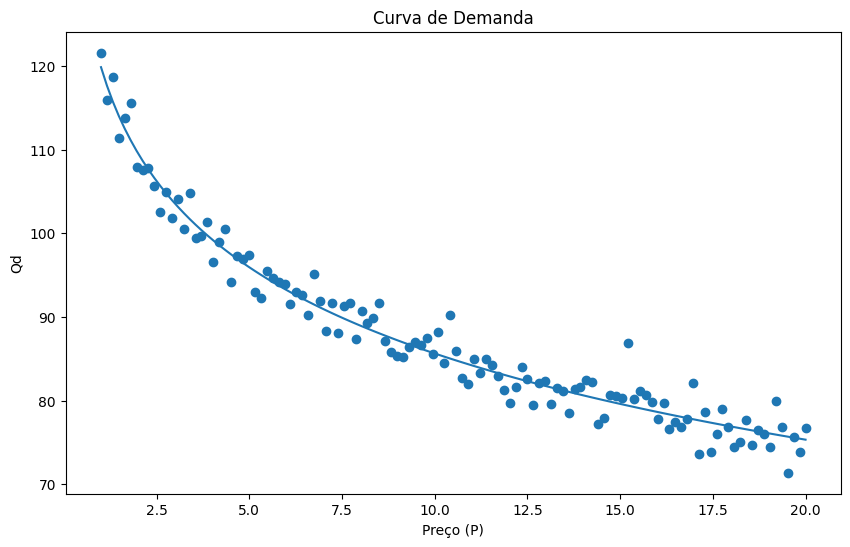

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

def C_Demanda(P, a, b):
    return a - b * np.log(P)

parameter = sp.optimize.curve_fit(C_Demanda,mercado['price_usd'],mercado['quantity_demand'])

a, b = parameter[0]

plt.figure(figsize=(10,6))
plt.scatter(mercado['price_usd'], mercado['quantity_demand'])
plt.plot(mercado['price_usd'], C_Demanda(mercado['price_usd'], a, b))
plt.xlabel('Preço (P)')
plt.ylabel('Qd')
plt.title('Curva de Demanda')
plt.show()

c = 5.120168986006044
d = 0.11847085610892823


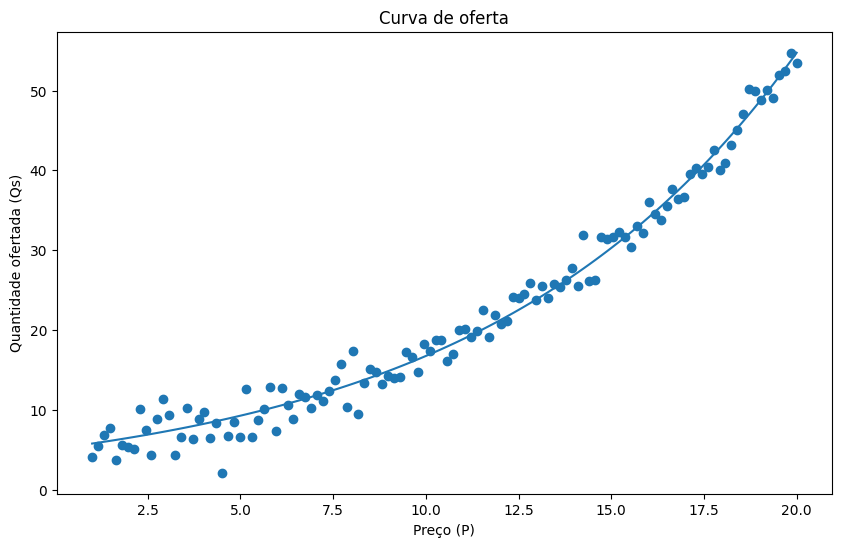

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

def C_Oferta(P, c, d):
    return c * np.exp(d * P)

parameter = sp.optimize.curve_fit(C_Oferta,mercado['price_usd'],mercado['quantity_supply'])

c, d = parameter[0]

print("c =", c)
print("d =", d)

plt.figure(figsize=(10, 6))
plt.scatter(mercado['price_usd'], mercado['quantity_supply'])
plt.plot(mercado['price_usd'], C_Oferta(mercado['price_usd'], c, d))
plt.xlabel('Preço (P)')
plt.ylabel('Quantidade ofertada (Qs)')
plt.title('Curva de oferta')
plt.show()

Parâmetros encontrados:
a=120.2965, b=15.0312, c=5.1468, d=0.1182


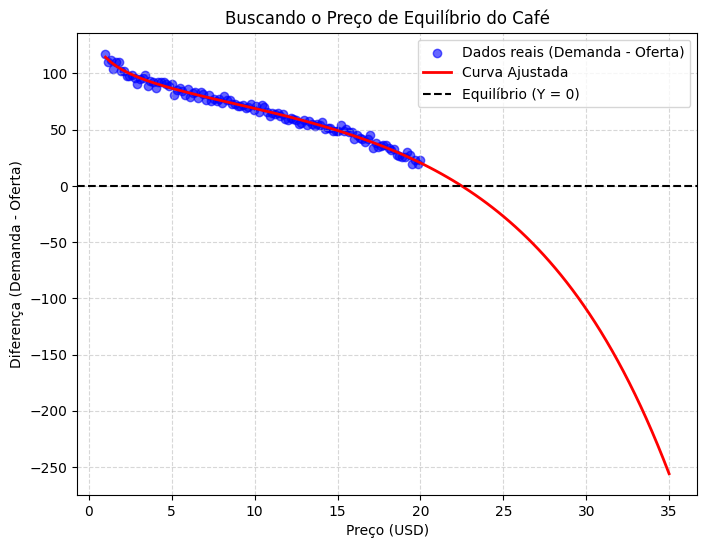


Resultado final: P = 22.495006493011008


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

# modelo da diferença: Qd(P) - Qs(P)
def modelo_equilibrio(P, a, b, c, d):
    return (a - b * np.log(P)) - (c * np.exp(d * P))

preco = mercado['price_usd'].values
demanda = mercado['quantity_demand'].values
oferta = mercado['quantity_supply'].values

diferenca = demanda - oferta

chute = [10.0, 1.0, 1.0, 0.01]

popt, pcov = sp.optimize.curve_fit(
    modelo_equilibrio,
    preco,
    diferenca,
    p0=chute,
    maxfev=10000,
    bounds=(0, np.inf)
)

a_otimizado, b_otimizado, c_otimizado, d_otimizado = popt

print(f"Parâmetros encontrados:")
print(f"a={a_otimizado:.4f}, b={b_otimizado:.4f}, c={c_otimizado:.4f}, d={d_otimizado:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(preco, diferenca, color='blue', alpha=0.6, label='Dados reais (Demanda - Oferta)')

limite_estendido = np.max(preco) + 15
x_continuo = np.linspace(np.min(preco), limite_estendido, 100)
plt.plot(x_continuo, modelo_equilibrio(x_continuo, *popt), color='red', linewidth=2, label='Curva Ajustada')

plt.axhline(0, color='black', linestyle='--', label='Equilíbrio (Y = 0)')

plt.xlabel('Preço (USD)')
plt.ylabel('Diferença (Demanda - Oferta)')
plt.title('Buscando o Preço de Equilíbrio do Café')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


"""
Visualmente, percebemos que a raiz toca o eixo X entre o intervalo [20, 25].
Sabendo também que os parâmetros otimizados foram: a=120.2965, b=15.0312, c=5.1468, d=0.1182.
Podemos usar o método de bisseção para a função: f(P) = (120.2965 - 15.0312 * np.log(P)) - (5.1468 * np.exp(0.1182 * P))
"""


tolerancia = 0.05
equacao = lambda P: (120.2965 - 15.0312 * np.log(P)) - (5.1468 * np.exp(0.1182 * P))

def f(P):
  return (120.2965 - 15.0312 * np.log(P)) - (5.1468 * np.exp(0.1182 * P))


a = 20
b = 25
def funcao():
    i=0
    x = 0
    global a,b
    ai =  a
    bi = b
    if (np.sign(f(a)) * np.sign(f(b))) != -1:
        return 0
    elif (np.sign(f(a)) * np.sign(f(b))) == -1:
        while(i < 1000):
            x = (ai + bi) / 2
            if(f(x) == 0):
                return x
            else:
               if np.sign(f(ai))*np.sign(f(x)) == -1:
                   bi = x
               else:
                   ai = x
            i = i+1
    return x





resultado = funcao()
print(f"\nResultado final: P = {resultado}")

